## Table of Contents:
* [1. Calculate metrics for footprint tools](#first-bullet)

In [11]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os, re, itertools
import pandas as pd
import numpy as np
from itertools import chain

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec

In [12]:
sns.set(style='whitegrid', rc={"figure.dpi":100, 'savefig.dpi':300})  
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

plt.rcParams['font.family'] = ['Arial', 'sans-serif']

color_scheme_cl = {"GM12878": "#267A9E", "MCF7": "#51A885", "K562":"#F5A936", "SKNSH": "#DB7476", "HEPG2": "#986B9B"}
color_scheme_prog = {"tobias":"#008080", "hint":"#CC5500", "print": "#A4254E", "pwm": "#97CECC"}
color_scheme_st = {"peakreads":"green", "cells":"#CE3B59", "frip":"#F5C23C", "reads":"#993CBE", "baseline":"black"}

# 1. Performance of non-downsampled samples

## Plots by F1 scores

In [13]:
#gather the tool performance
#across downsampling, but then limit to the non-downsampled files. 
df = pd.concat([pd.read_csv(f"../11_chip/HEPG2/downsampling_metrics.csv.gz", sep=","),
                pd.read_csv(f"../11_chip/K562/downsampling_metrics.csv.gz", sep=","),
                pd.read_csv(f"../11_chip/SKNSH/downsampling_metrics.csv.gz", sep=","),
                pd.read_csv(f"../11_chip/MCF7/downsampling_metrics.csv.gz", sep=","),
                pd.read_csv(f"../11_chip/GM12878/downsampling_metrics.csv.gz", sep=",")]
)

df[["cell_line", "condition", "seed_rep"]] = df["file"].str.split("_", expand=True)
df["sampling_type"] =  df["condition"].str[0].astype("string")
nondown = [f for f in np.unique(df.file) if "-cellFilt" in f]
df.loc[df["file"].isin(nondown), "sampling_type"] = "baseline"
df['cell_line'] = df['cell_line'].str.replace('-cellFilt', '', regex=False)
df["cell_line"] = pd.Categorical(df["cell_line"], categories=["K562", "HEPG2", "MCF7", "SKNSH", "GM12878"], ordered=True)
df["tool"] = pd.Categorical(df["tool"], categories=["hint", "print", "tobias", "pwm"], ordered=True)
display(df)

base_df = df[(df["sampling_type"] == "baseline") & (df["shuffled"] == False)]

,TP,FP,FN,TN,total foot,total chip,precision,recall,f1,fpr,shuffled,motif,chipd_tf,file,tool,cell_line,condition,seed_rep,sampling_type
0,638,3207,7612,426300,3845,8250,0.1659,0.0773,0.1055,0.0075,False,ATF2_MA1632.1,ATF2,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r
1,62,3783,8188,425724,3845,8250,0.0161,0.0075,0.0103,0.0088,True,ATF2_MA1632.1,ATF2,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r
2,385,617,8388,428367,1002,8773,0.3842,0.0439,0.0788,0.0014,False,ATF7_MA0834.1,ATF7,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r
3,18,984,8755,428000,1002,8773,0.0180,0.0021,0.0037,0.0023,True,ATF7_MA0834.1,ATF7,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r
4,547,4506,4595,428109,5053,5142,0.1083,0.1064,0.1073,0.0104,False,BACH1_MA1633.2,BACH1,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11215,32818,367912,7431,82205,400730,40249,0.0819,0.8154,0.1488,0.8174,True,TCF3_MA0522.3,TCF3,GM12878-cellFilt,pwm,GM12878,None,None,baseline
11216,25854,303131,3549,157832,328985,29403,0.0786,0.8793,0.1443,0.6576,False,ZEB1_MA0103.3,ZEB1,GM12878-cellFilt,pwm,GM12878,None,None,baseline
11217,19674,309311,9729,151652,328985,29403,0.0598,0.6691,0.1098,0.6710,True,ZEB1_MA0103.3,ZEB1,GM12878-cellFilt,pwm,GM12878,None,None,baseline
11218,5713,146524,6456,331673,152237,12169,0.0375,0.4695,0.0695,0.3064,False,ZNF24_MA1124.1,ZNF24,GM12878-cellFilt,pwm,GM12878,None,None,baseline


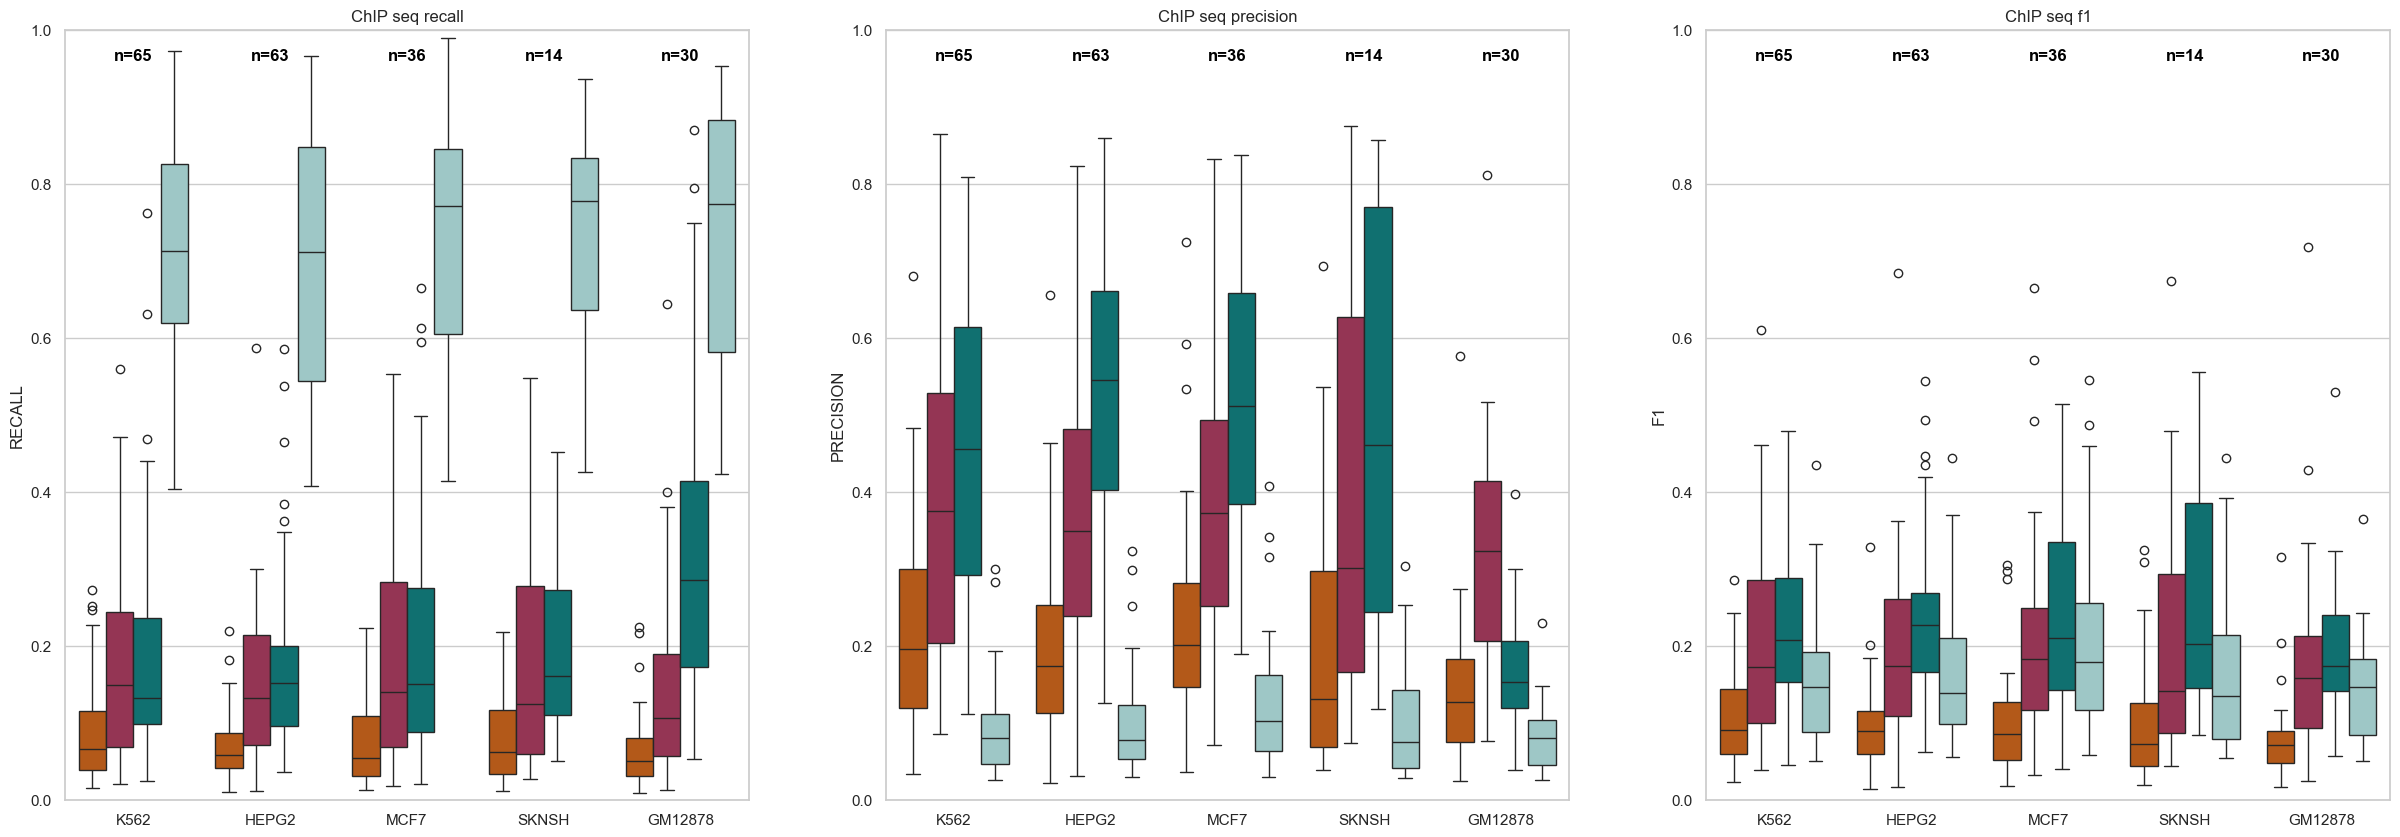

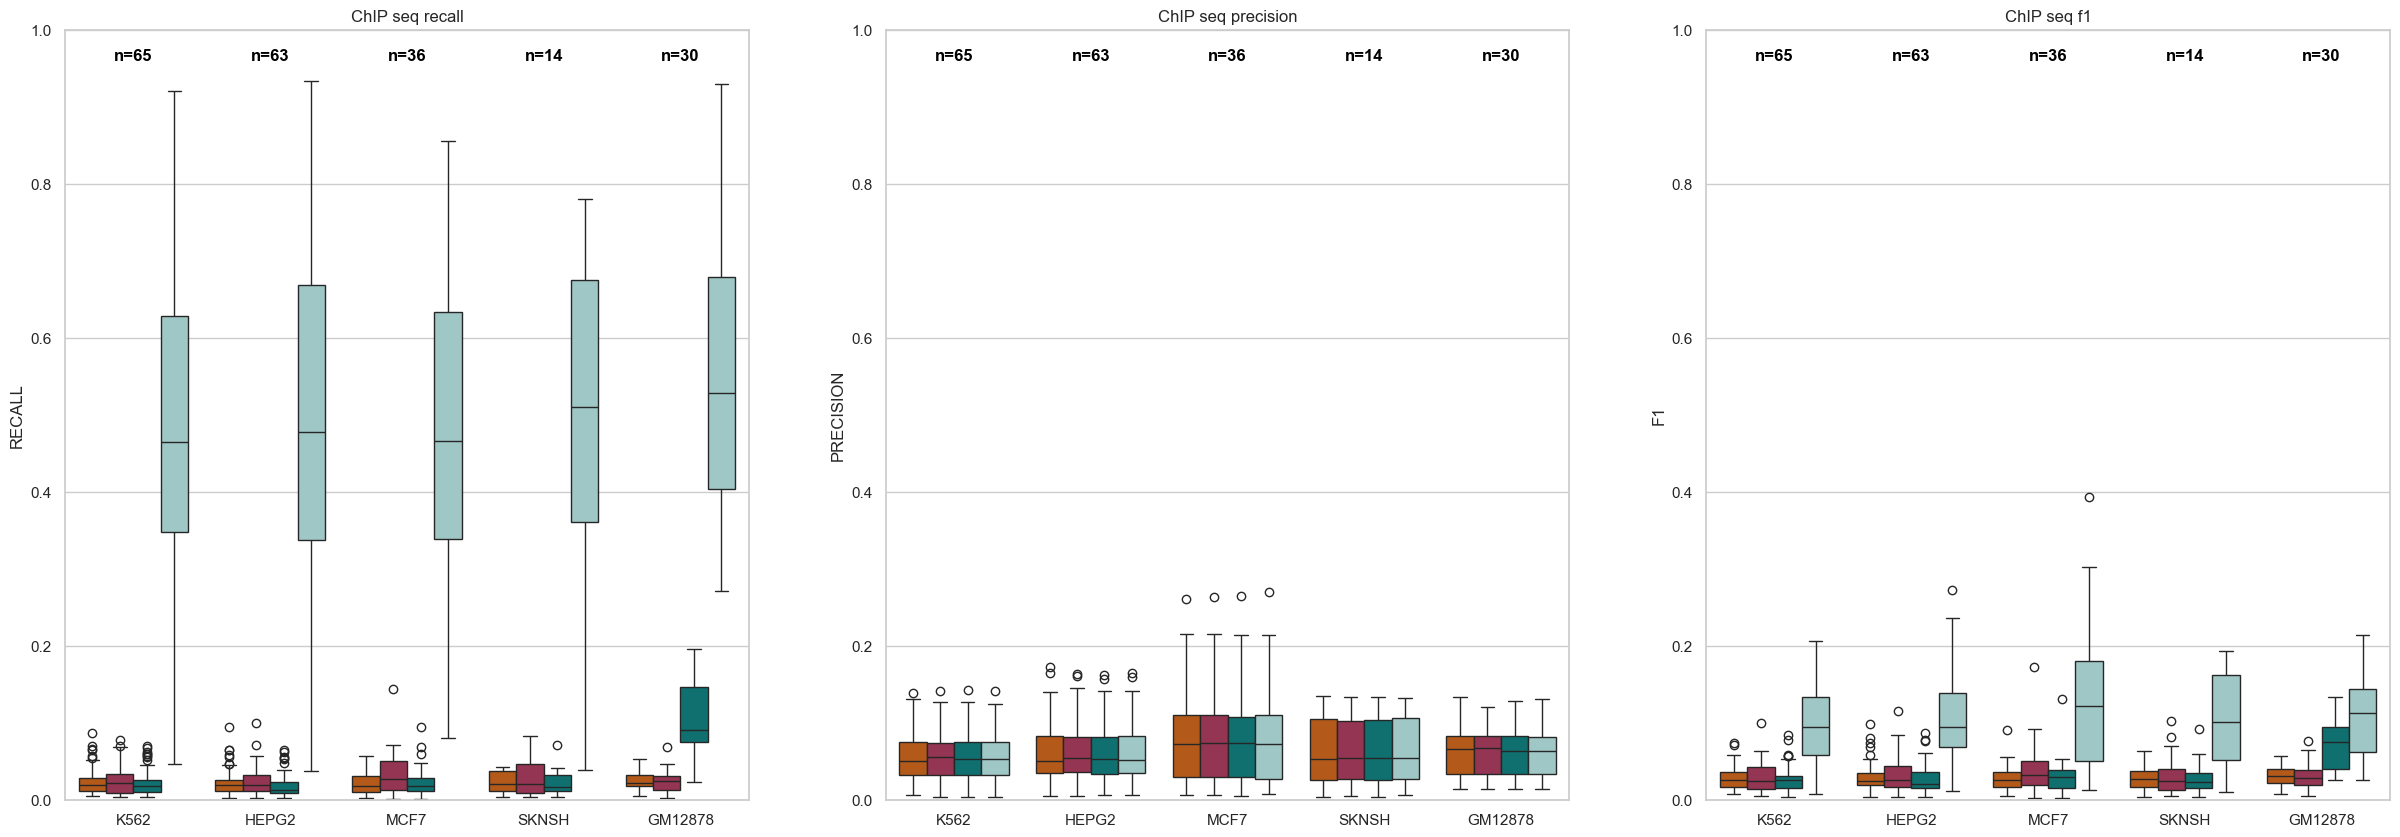

In [14]:
def _boxplotter(df, ax, metric):
    sns.boxplot(x="cell_line", y=metric, hue="tool", data=df, palette=color_scheme_prog, ax=ax)
    ax.set_title(f"ChIP seq {metric}")
    ax.set_ylabel(metric.upper())
    ax.set_xlabel("")
    ax.get_legend().remove()
    ax.set_ylim(0, 1)
    for cl, sub_df in df.groupby("cell_line"):
        count = len(np.unique(sub_df["motif"]))
        ax.text(cl, 0.96, f'n={count}', horizontalalignment='center', size='medium', color='black', weight='semibold')
    return ax

fig = plt.figure(figsize=(30,10))
gs = GridSpec(1, 3, figure=fig)

ax0 = fig.add_subplot(gs[0])
ax0 = _boxplotter(base_df, ax0, "recall")

ax1 = fig.add_subplot(gs[1])
ax1 = _boxplotter(base_df, ax1, "precision")

ax2 = fig.add_subplot(gs[2])
ax2 = _boxplotter(base_df, ax2, "f1")

plt.show()


fig = plt.figure(figsize=(30,10))
gs = GridSpec(1, 3, figure=fig)

tmp = df[(df["sampling_type"] == "baseline") & (df["shuffled"] == True)]
ax0 = fig.add_subplot(gs[0])
ax0 = _boxplotter(tmp, ax0, "recall")

ax1 = fig.add_subplot(gs[1])
ax1 = _boxplotter(tmp, ax1, "precision")

ax2 = fig.add_subplot(gs[2])
ax2 = _boxplotter(tmp, ax2, "f1")

plt.show()


## Plots by percentage of support

In [15]:
def _getOverlaps(group, pwm_df, foot_df, chip_df):
    tf = group["ChIPd_TF"]
    motif = group["BestMotif"]

    full_data = pd.DataFrame({'TFBS': pwm_df[motif].to_numpy().flatten(),
                              'Footprinting': foot_df[motif].to_numpy().flatten(),
                              'ChIP': chip_df[tf].to_numpy().flatten()})

    chip_cond = (full_data["ChIP"]>0)
    tfbs_cond = (full_data["TFBS"]>0)
    foot_cond = (full_data["Footprinting"]>0)

    # [chip, chipwPWM, chipwFoot, chipwPWMwFoot, tfbswFoot, tfbswChIP]
    val = [full_data[chip_cond].shape[0],
           full_data[chip_cond & tfbs_cond].shape[0],
           full_data[chip_cond & foot_cond].shape[0],
           full_data[chip_cond & tfbs_cond & foot_cond].shape[0],
           full_data[tfbs_cond & foot_cond].shape[0],
           full_data[tfbs_cond & chip_cond].shape[0]
          ]
    return val


    
colname = ["Num_ChIP", 
           "Num_ChIP_wTFBS", 
           "Num_ChIP_wFoot", 
           "Num_ChIP_wTFBS_wFoot", 
           "Num_TFBS_wFoot", 
           "Num_TFBS_wChIP"]

res_list = list()

for cl in ["HEPG2"]: #, "HEPG2", "SKNSH", "MCF7"]:
    chip_df = pd.read_csv(f"../11_chip/{cl}/chip.mat.gz", sep=",", index_col="region_atac")
    pwm_df  = pd.read_csv(f"../../06_dataquality/pwm/mats/{cl}-cellFilt.mat", index_col=0)

    motif_to_tf  = pd.read_csv(f"../11_chip/{cl}/motif_performance.csv.gz", sep=",")
    motif_to_tf = motif_to_tf.dropna()
    motif_to_tf["cell_line"] = cl
    
    for tool in ["hint", "print", "tobias"]:
        #print(tool)
        if tool == "tobias":
            ddir = f"../../06_dataquality/tobias/mats/bound_threshold/{cl}-cellFilt.mat" 
        elif tool == "print":
            ddir = f"../../06_dataquality/print/mats/thresh_03/{cl}-cellFilt.mat"
        else:
            ddir = f"../../06_dataquality/{tool}/mats/{cl}-cellFilt.mat" 
            
        wip = motif_to_tf.copy()
        wip["tool"] = tool
        foot_df = pd.read_csv(ddir, index_col=0)

        wip[colname] = wip.apply(_getOverlaps, axis=1, result_type='expand', args=(pwm_df, foot_df, chip_df,))
        res_list.append(wip)

res_df = pd.concat(res_list)
display(res_df)

,ChIPd_TF,BestMotif,name,cell_line,tool,Num_ChIP,Num_ChIP_wTFBS,Num_ChIP_wFoot,Num_ChIP_wTFBS_wFoot,Num_TFBS_wFoot,Num_TFBS_wChIP
4,ATF2,ATF2_MA1632.1,ATF2 (ATF2_MA1632.1),HEPG2,hint,8250,7343,1231,1231,8032,7343
7,ATF7,ATF7_MA0834.1,ATF7 (ATF7_MA0834.1),HEPG2,hint,8773,3900,707,707,2163,3900
8,BACH1,BACH1_MA1633.2,BACH1 (BACH1_MA1633.2),HEPG2,hint,5142,3695,778,778,11175,3695
9,BHLHE40,BHLHE40_MA0464.2,BHLHE40 (BHLHE40_MA0464.2),HEPG2,hint,27943,11789,1058,1057,3186,11789
10,CEBPA,CEBPA_MA0102.4,CEBPA (CEBPA_MA0102.4),HEPG2,hint,26351,24095,2747,2747,9036,24095
...,...,...,...,...,...,...,...,...,...,...,...
121,ZBTB7B,ZBTB7B_MA0694.1,ZBTB7B (ZBTB7B_MA0694.1),HEPG2,tobias,55497,22643,2056,2056,4187,22643
122,ZEB1,ZEB1_MA0103.3,ZEB1 (ZEB1_MA0103.3),HEPG2,tobias,11028,9348,2830,2830,12607,9348
126,ZNF263,ZNF263_MA0528.2,ZNF263 (ZNF263_MA0528.2),HEPG2,tobias,37094,35830,11749,11749,21038,35830
129,ZNF384,ZNF384_MA1125.1,ZNF384 (ZNF384_MA1125.1),HEPG2,tobias,35012,25106,5354,5354,7957,25106


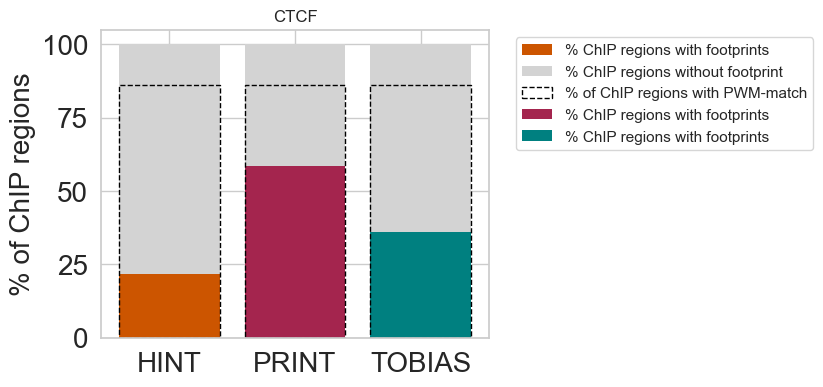

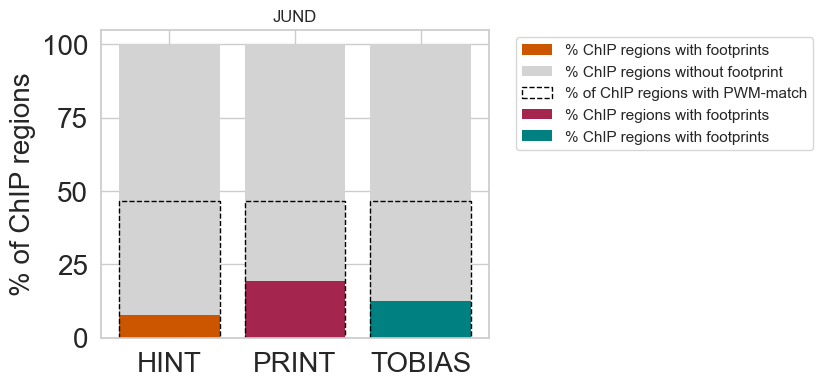

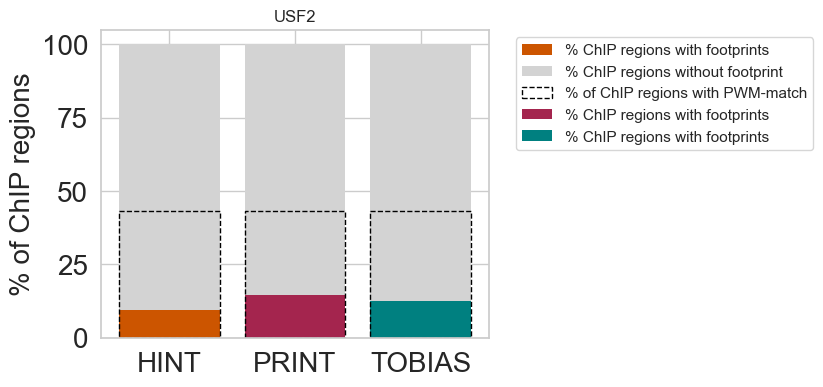

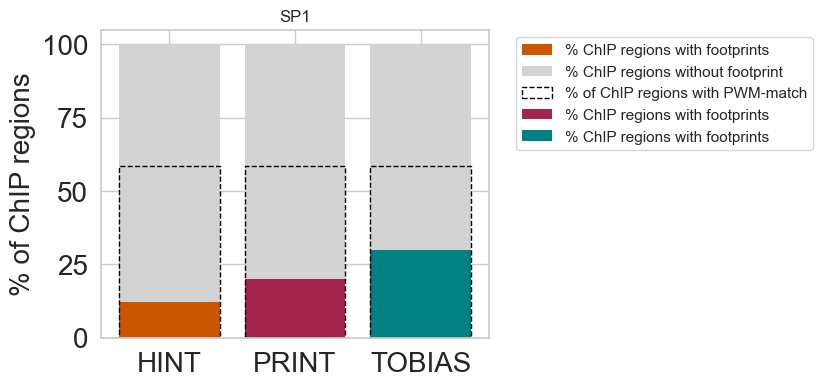

In [16]:
def _stackedbar(tf, cl):
    tmp = res_df[res_df["ChIPd_TF"] == tf]
    
    denom = tmp["Num_ChIP_wTFBS"].values[0]
    pwm_percent = (tmp["Num_ChIP_wTFBS"]/tmp["Num_ChIP"]).values[0] * 100
    
    hint_decimal   = (tmp[tmp["tool"] == "hint"]["Num_ChIP_wTFBS_wFoot"])/denom
    tobias_decimal = (tmp[tmp["tool"] == "tobias"]["Num_ChIP_wTFBS_wFoot"])/denom
    print_decimal  = (tmp[tmp["tool"] == "print"]["Num_ChIP_wTFBS_wFoot"])/denom
    
    fig, ax = plt.subplots(figsize=(5, 4))
    v = pwm_percent*hint_decimal
    ax.bar("HINT", v, bottom=0, color=color_scheme_prog["hint"], 
           label="% ChIP regions with footprints", linewidth=0)
    ax.bar("HINT", 100-v, bottom=v, color="lightgrey", 
           label="% ChIP regions without footprint", linewidth=0)
    ax.bar("HINT", pwm_percent, bottom=0, facecolor='none', edgecolor='black', linewidth=1, linestyle="dashed", label="% of ChIP regions with PWM-match")
    
    v = pwm_percent*print_decimal
    ax.bar("PRINT", v, bottom=0, color=color_scheme_prog["print"], 
           label="% ChIP regions with footprints", linewidth=0)
    ax.bar("PRINT", 100-v, bottom=v, color="lightgrey", linewidth=0)
    ax.bar("PRINT", pwm_percent, bottom=0, facecolor='none', edgecolor='black', linewidth=1, linestyle="dashed")

    v = pwm_percent*tobias_decimal
    ax.bar("TOBIAS", v, bottom=0, color=color_scheme_prog["tobias"], 
           label="% ChIP regions with footprints", linewidth=0)
    ax.bar("TOBIAS", 100-v, bottom=v, color="lightgrey", linewidth=0)
    ax.bar("TOBIAS", pwm_percent, bottom=0, facecolor='none', edgecolor='black', linewidth=1, linestyle="dashed")
    
    ax.set_xlabel('')
    ax.set_ylabel('% of ChIP regions', fontsize=20)
    ax.set_title(tf)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="")
    ax.tick_params(axis='both', labelsize=20)
    
    plt.show()
    return

_stackedbar("CTCF", cl)
_stackedbar("JUND", cl)
_stackedbar("USF2", cl)
_stackedbar("SP1", cl)

# 2. Performance across downsampling

In [17]:
df = pd.concat([pd.read_csv(f"../11_chip/HEPG2/downsampling_metrics.csv.gz", sep=","),
                pd.read_csv(f"../11_chip/K562/downsampling_metrics.csv.gz", sep=","),
                pd.read_csv(f"../11_chip/SKNSH/downsampling_metrics.csv.gz", sep=","),
                pd.read_csv(f"../11_chip/MCF7/downsampling_metrics.csv.gz", sep=",")]
)

df = df[df.shuffled == False]
df = df[df.tool != "pwm"]

df[["cell_line", "condition", "seed_rep"]] = df["file"].str.split("_", expand=True)
df["sampling_type"] =  df["condition"].str[0].astype("string")
df["xaxis"] =  df["condition"].str[1:].astype("float")

mask1 = (df["sampling_type"] == "f") & (df["xaxis"].isin([5, 25, 35]))
mask2 = (df["sampling_type"] == "f") & (df["xaxis"].isin([1,2,4,6,8]))
df.loc[mask1, "xaxis"] /= 100
df.loc[mask2, "xaxis"] /= 10

nondown = [f for f in np.unique(df.file) if "-cellFilt" in f]
df.loc[df["file"].isin(nondown), "sampling_type"] = "baseline"
df['cell_line'] = df['cell_line'].str.replace('-cellFilt', '', regex=False)

df["tpr"] = df["TP"]/(df["TP"] + df["FN"])
df["fpr"] = df["FP"]/(df["FP"] + df["TN"])
display(df)


,TP,FP,FN,TN,total foot,total chip,precision,recall,f1,fpr,...,motif,chipd_tf,file,tool,cell_line,condition,seed_rep,sampling_type,xaxis,tpr
0,638,3207,7612,426300,3845,8250,0.1659,0.0773,0.1055,0.007467,...,ATF2_MA1632.1,ATF2,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r,5000000.0,0.077333
2,385,617,8388,428367,1002,8773,0.3842,0.0439,0.0788,0.001438,...,ATF7_MA0834.1,ATF7,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r,5000000.0,0.043885
4,547,4506,4595,428109,5053,5142,0.1083,0.1064,0.1073,0.010416,...,BACH1_MA1633.2,BACH1,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r,5000000.0,0.106379
6,773,850,27170,408964,1623,27943,0.4763,0.0277,0.0523,0.002074,...,BHLHE40_MA0464.2,BHLHE40,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r,5000000.0,0.027663
8,1587,2527,24764,408879,4114,26351,0.3858,0.0602,0.1042,0.006142,...,CEBPA_MA0102.4,CEBPA,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r,5000000.0,0.060225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13814,4554,5956,39438,327481,10510,43992,0.4333,0.1035,0.1671,0.017862,...,TEAD4_MA0809.2,TEAD4,MCF7_f02_s59,print,MCF7,f02,s59,f,0.2,0.103519
13816,2554,6936,25534,342405,9490,28088,0.2691,0.0909,0.1359,0.019855,...,TFAP2A_MA0872.1,TFAP2A,MCF7_f02_s59,print,MCF7,f02,s59,f,0.2,0.090929
13818,6521,5792,38942,326174,12313,45463,0.5296,0.1434,0.2257,0.017448,...,TFAP2C_MA0524.2,TFAP2C,MCF7_f02_s59,print,MCF7,f02,s59,f,0.2,0.143435
13820,1622,4081,32345,339381,5703,33967,0.2844,0.0478,0.0818,0.011882,...,TRPS1_MA1970.1,TRPS1,MCF7_f02_s59,print,MCF7,f02,s59,f,0.2,0.047752


In [18]:
all_metrics = pd.read_csv("../04_downsampling/sampling_stats.csv.gz", sep=",", index_col=0)
all_metrics = all_metrics[all_metrics["sampling_type"] == "baseline"]

res = [df]

for cl in ['HEPG2', 'K562', 'MCF7', 'SKNSH']:
    sub = df[(df['sampling_type'] == "baseline") & (df["cell_line"] == cl)]
    for st, col in [("c", "Ncells"), ("r", "Nreadpairs"), ("f", "FRIP")]:
        sub2 = sub.copy()
        sub2["sampling_type"] = st
        sub2["xaxis"] = all_metrics.loc[cl][col]
        res.append(sub2)

df = pd.concat(res)
display(df)

,TP,FP,FN,TN,total foot,total chip,precision,recall,f1,fpr,...,motif,chipd_tf,file,tool,cell_line,condition,seed_rep,sampling_type,xaxis,tpr
0,638,3207,7612,426300,3845,8250,0.1659,0.0773,0.1055,0.007467,...,ATF2_MA1632.1,ATF2,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r,5000000.000,0.077333
2,385,617,8388,428367,1002,8773,0.3842,0.0439,0.0788,0.001438,...,ATF7_MA0834.1,ATF7,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r,5000000.000,0.043885
4,547,4506,4595,428109,5053,5142,0.1083,0.1064,0.1073,0.010416,...,BACH1_MA1633.2,BACH1,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r,5000000.000,0.106379
6,773,850,27170,408964,1623,27943,0.4763,0.0277,0.0523,0.002074,...,BHLHE40_MA0464.2,BHLHE40,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r,5000000.000,0.027663
8,1587,2527,24764,408879,4114,26351,0.3858,0.0602,0.1042,0.006142,...,CEBPA_MA0102.4,CEBPA,HEPG2_r5e6_s55,hint,HEPG2,r5e6,s55,r,5000000.000,0.060225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5506,5724,5937,39965,383590,11661,45689,0.4909,0.1253,0.1996,0.015242,...,NFIC::TLX1_MA0119.1,NFIC,SKNSH-cellFilt,print,SKNSH,None,None,f,0.285,0.125282
5508,429,3069,15608,416110,3498,16037,0.1226,0.0268,0.0439,0.007321,...,PPARA::RXRA_MA1148.1,RXRA,SKNSH-cellFilt,print,SKNSH,None,None,f,0.285,0.026751
5510,2665,7607,23123,401821,10272,25788,0.2594,0.1033,0.1478,0.018580,...,TEAD4_MA0809.2,TEAD4,SKNSH-cellFilt,print,SKNSH,None,None,f,0.285,0.103343
5512,4071,1983,28785,400377,6054,32856,0.6724,0.1239,0.2093,0.004928,...,USF1_MA0093.3,USF1,SKNSH-cellFilt,print,SKNSH,None,None,f,0.285,0.123904


In [19]:
samsies = ["cell_line", "condition", "tool", "xaxis", "sampling_type"]
mean_df = df.groupby(samsies)[["precision", "recall", "f1"]].apply(lambda col: col.mean())
std_df  = df.groupby(samsies)[["precision", "recall", "f1"]].apply(lambda col: col.std())

byGroup_df = pd.concat([mean_df.add_suffix('_mean'), std_df.add_suffix('_sd')], axis=1)
byGroup_df.reset_index(inplace=True)
display(byGroup_df)

,cell_line,condition,tool,xaxis,sampling_type,precision_mean,recall_mean,f1_mean,precision_sd,recall_sd,f1_sd
0,HEPG2,c1000,hint,1000.0,c,0.253516,0.067565,0.096992,0.133381,0.041119,0.048330
1,HEPG2,c1000,print,1000.0,c,0.651466,0.056716,0.097452,0.205675,0.051906,0.076231
2,HEPG2,c1000,tobias,1000.0,c,0.283234,0.270834,0.245406,0.133157,0.134979,0.093563
3,HEPG2,c10000,hint,10000.0,c,0.198822,0.070716,0.093940,0.120398,0.043873,0.051518
4,HEPG2,c10000,print,10000.0,c,0.428805,0.134490,0.186086,0.193186,0.091822,0.107560
...,...,...,...,...,...,...,...,...,...,...,...
253,SKNSH,r5e7,print,50000000.0,r,0.552136,0.115774,0.174245,0.285004,0.115135,0.160654
254,SKNSH,r5e7,tobias,50000000.0,r,0.365321,0.271840,0.284357,0.223290,0.157523,0.170299
255,SKNSH,r5e8,hint,500000000.0,r,0.223583,0.084564,0.113955,0.203374,0.066754,0.099801
256,SKNSH,r5e8,print,500000000.0,r,0.396167,0.173674,0.219262,0.262285,0.152041,0.187830


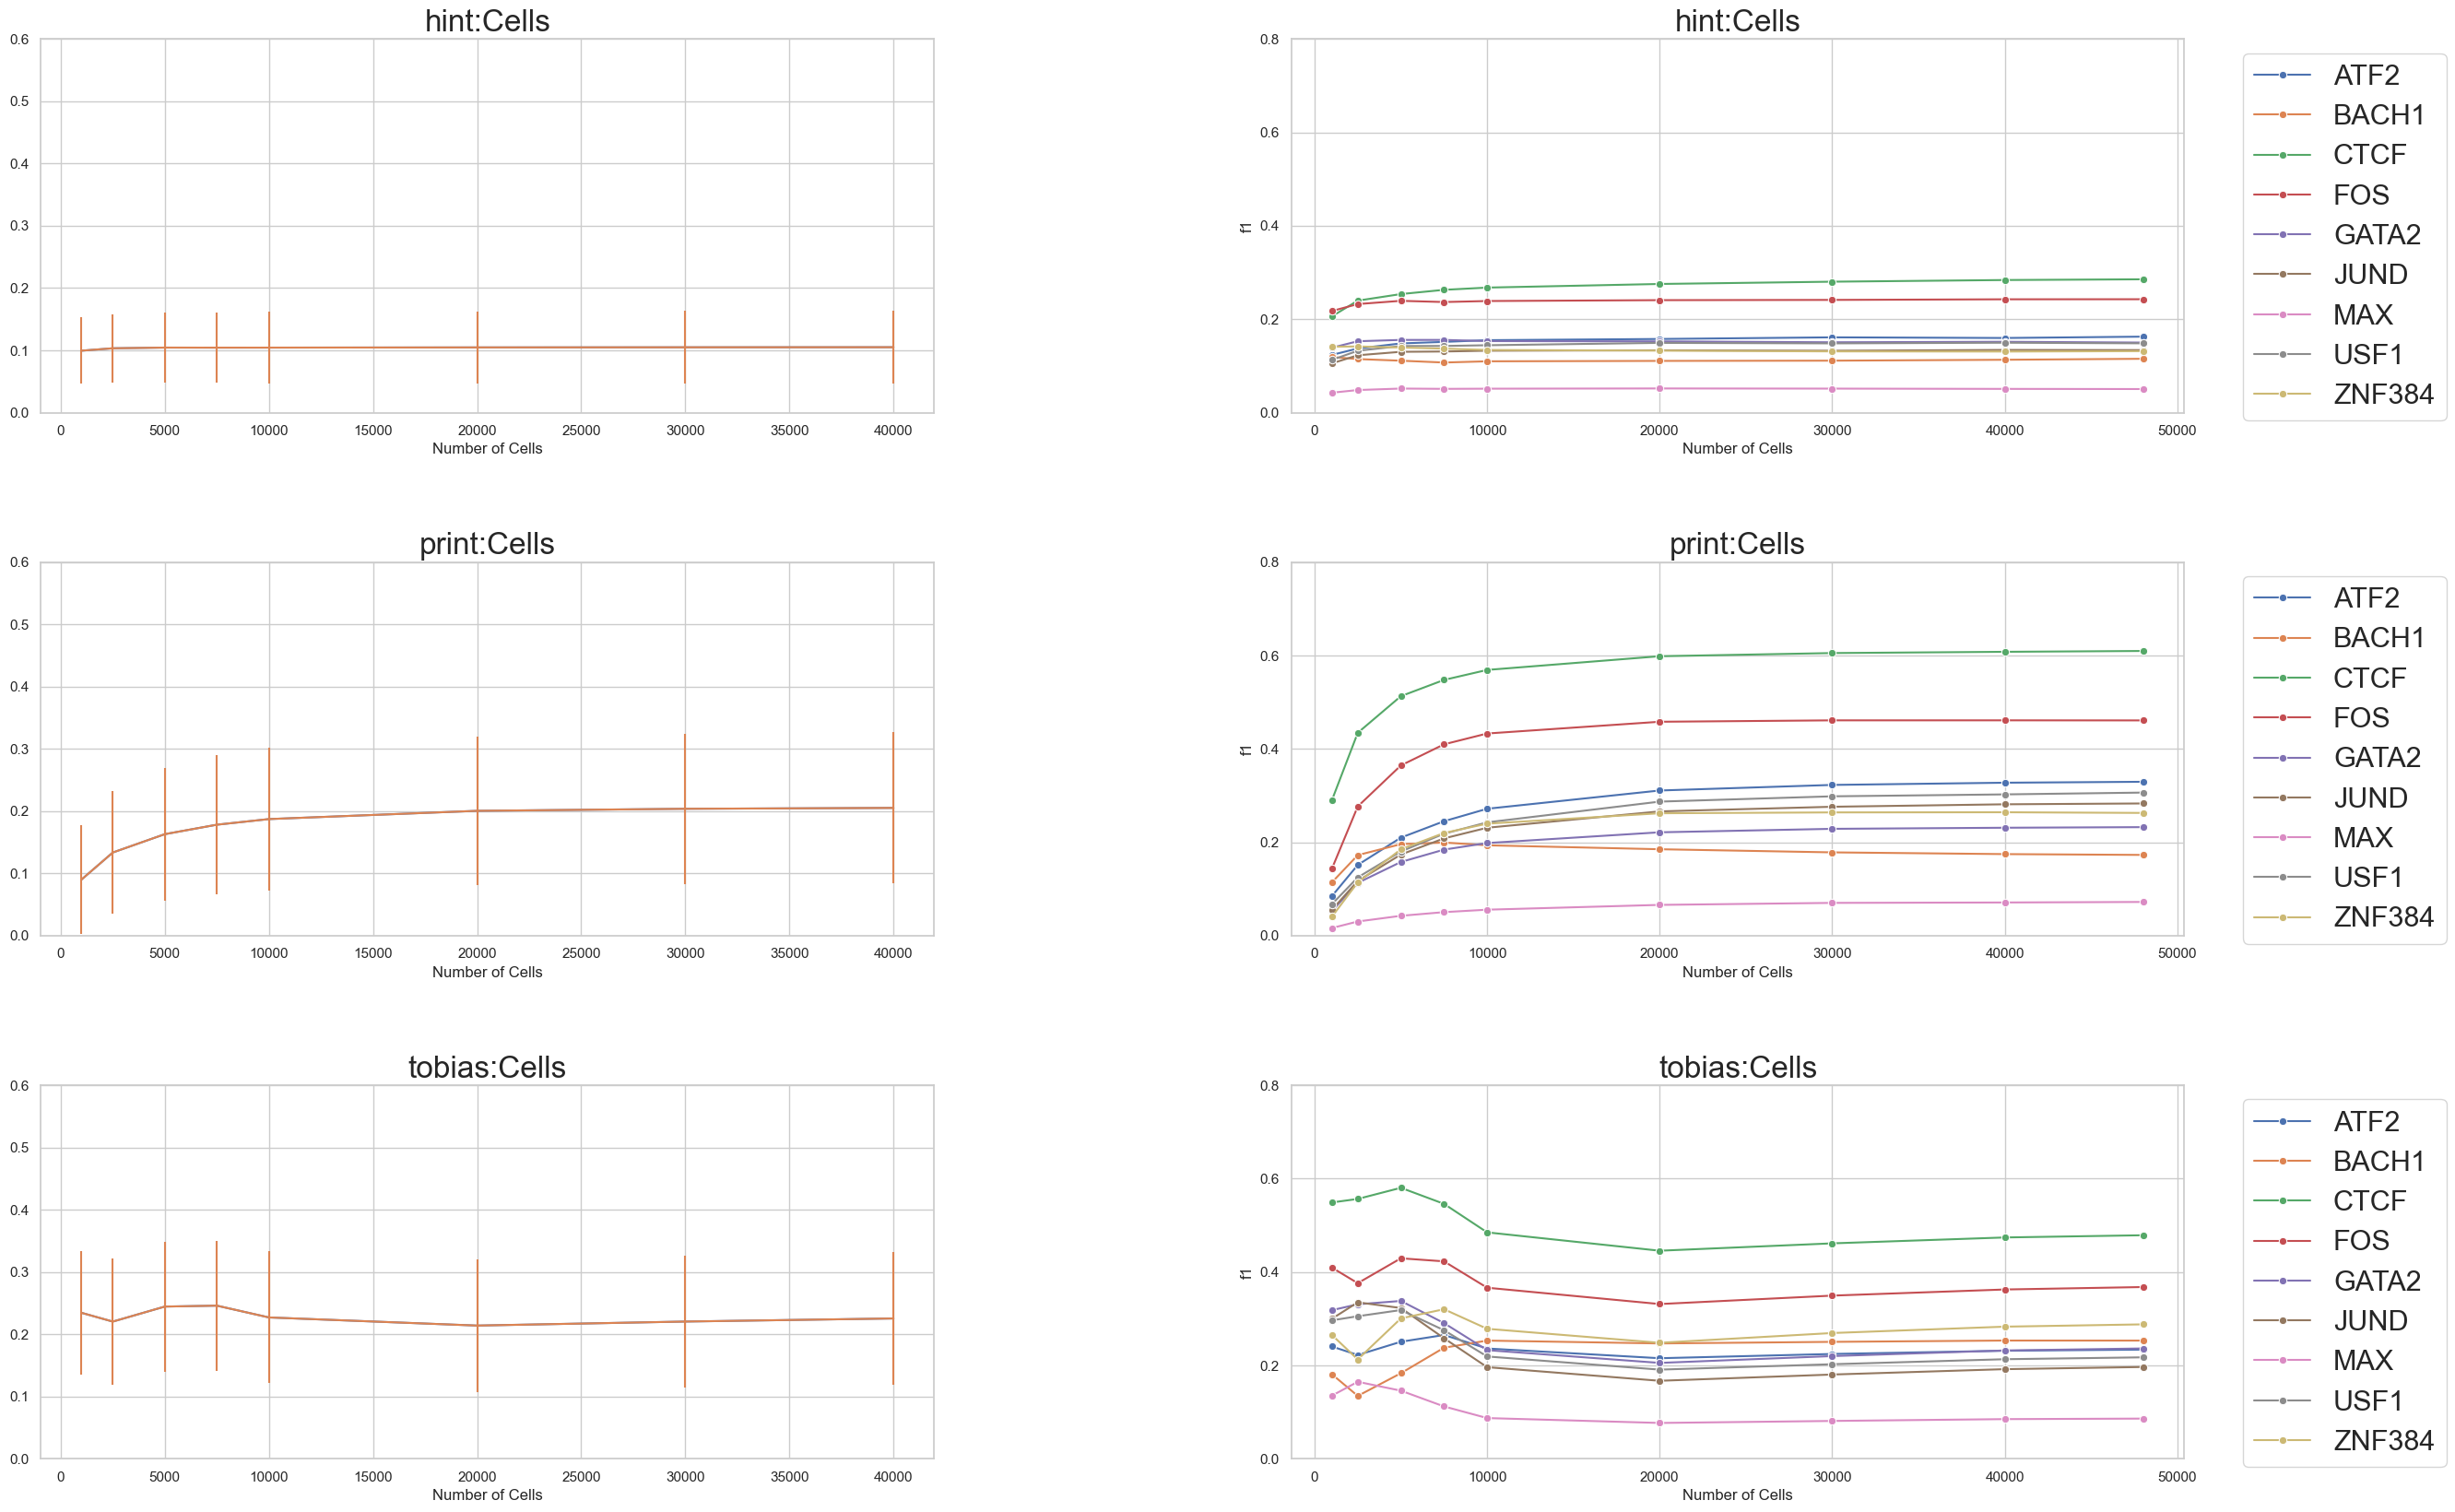

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(30,20))
axes = axes.flatten()  # Flatten to iterate easily
plt.subplots_adjust(wspace=0.4, hspace=0.4)
sns.set(font_scale=2, style='whitegrid')

cl = "K562"
st = "c"
tfs = ['ATF2', 'BACH1', 'CTCF', 'FOS', 'GATA2', 'JUND', 'MAX',  'USF1', 'ZNF384']


sub_df1 = byGroup_df[(byGroup_df["sampling_type"] == st) & (byGroup_df["cell_line"] == cl)]
sub_df2 = df[(df["chipd_tf"].isin(tfs)) & (df["cell_line"] == cl) & (df["sampling_type"] == st)]

for tool, i in zip(["hint", "print", "tobias"], [0,2,4]):
    st = "c"

    ax0 = axes[i]
    tmp = sub_df1[sub_df1["tool"] == tool]
    obj = zip(tmp["xaxis"].to_list(), tmp["f1_mean"].to_list(), tmp["f1_sd"].to_list())
    myx, myy, mye = zip(*sorted(obj))
    ax0.plot(myx, myy)
    ax0.errorbar(myx, myy, yerr=mye)
    ax0.set_title(f"{tool}:Cells")
    ax0.set_xlabel("Number of Cells")
    ax0.set_ylim(0, 0.6)
    
    
    ax0 = axes[i+1]
    tmp = sub_df2[sub_df2["tool"] == tool]
    sns.lineplot(data=tmp, x="xaxis", y="f1", hue="chipd_tf", ax = ax0, marker="o", ci=None)
    ax0.set_title(f"{tool}:Cells")
    ax0.set_xlabel("Number of Cells")
    ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="")
    ax0.set_ylim(0, 0.8)
                  
plt.show()